# ANNNI model with time evolution
Taken and adapted from <https://pennylane.ai/qml/demos/tutorial_quantum_phase_transitions>

## Create the hamiltonian

In [1]:
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as np
from VQE import VQE
import energy
import math
from jax import numpy as jnp
from jax import vmap
from scipy.linalg import expm
import torch
import numpy as np

In [2]:


N = 5
k_train = 0.5
h_train = 0.5

k_val = 0.0
h_val = 1.0

wires = range(N)

dev = qml.device("lightning.qubit", wires=N)

def get_H(num_spins, k, h):
    """Construction function the ANNNI Hamiltonian (J=1)"""

    # Interaction between spins (neighbouring):
    H = -1 * (qml.PauliX(0) @ qml.PauliX(1))
    for i in range(1, num_spins - 1):
        H = H  - (qml.PauliX(i) @ qml.PauliX(i + 1))

    # Interaction between spins (next-neighbouring):
    for i in range(0, num_spins - 2):
        H = H + k * (qml.PauliX(i) @ qml.PauliX(i + 2))

    # Interaction of the spins with the magnetic field
    for i in range(0, num_spins):
        H = H - h * qml.PauliZ(i)

    return H

H = get_H(N,k_val,h_val) 

print(f"H = {H}")  


H = -1 * (X(0) @ X(1)) + -1 * (X(1) @ X(2)) + -1 * (X(2) @ X(3)) + -1 * (X(3) @ X(4)) + 0.0 * (X(0) @ X(2)) + 0.0 * (X(1) @ X(3)) + 0.0 * (X(2) @ X(4)) + -1.0 * Z(0) + -1.0 * Z(1) + -1.0 * Z(2) + -1.0 * Z(3) + -1.0 * Z(4)


## Use VQE to find the Ground State

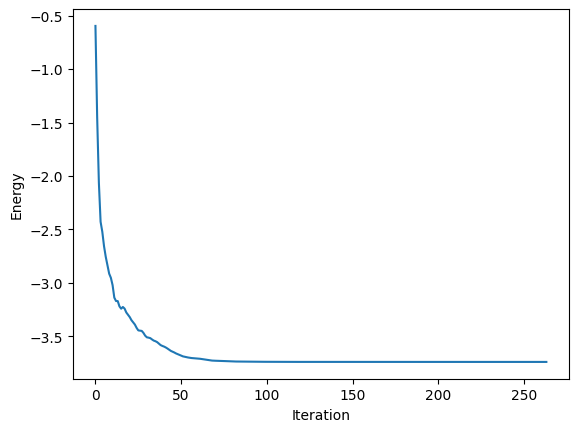

-3.7398289712139166


In [3]:
# create an ansatz using the hardware efficiency ansatz (HEA)
def create_ansatz(params, N):
    # STEP 1: perform single-qubit rotations on all the qubits
    for i in range(N):
        qml.RZ(phi=params[i], wires=i)
        qml.RX(phi=params[N + i], wires=i)
        qml.RZ(phi=params[2 * N + i], wires=i)

    # STEP 2: perform a CNOT gate on each pair of neighbouring qubits
    for i in range(N - 1):
        qml.CNOT(wires=[i, i + 1])

    # STEP 3: perform single-qubit rotations on all the qubits
    for i in range(N):
        qml.RZ(phi=params[3 * N + i], wires=i)
        qml.RX(phi=params[4 * N + i], wires=i)
        qml.RZ(phi=params[5 * N + i], wires=i)



# def find_ground_state(N,k,h, max_iters = 200, tolerance = 1e-04, seed=None):
#     # This function applies the VQE to find the ground state of a given hamiltonian
#     # max_iters = 200, tolerance = 1e-04

#     H_ = get_H(N,k,h)
    
#     import random
#     if seed is None:
#         random.seed()
#     else:
#         random.seed(a=seed)
    
#     # params is an array that stores the parameter values of the statevector that we use in VQE.
#     # Generate some initial random angle values.
#     params = np.array([2 * np.pi * random.uniform(0, 1)] * (6 * N), requires_grad=True)


#     @qml.qnode(dev)
#     def quantum_circuit(params):
#         # Create a quantum state using params
#         create_ansatz(params, N)
#         return qml.expval(H_)
    


#     # create an optimizer
#     opt = qml.GradientDescentOptimizer(stepsize=0.1)
    
#     # energy is a list that stores all the estimates for the ground-state energy
#     energy = []
    
#     # execute the VQE optimization loop
#     for i in range(max_iters):
#         params, prev_energy = opt.step_and_cost(quantum_circuit, params)
#         energy.append(prev_energy)
    
#         if i > 1:
#             if np.abs(energy[-2] - energy[-1]) < tolerance:
#                 break

#     return params, energy

# params, energy = find_ground_state(N, k, h, max_iters=500, tolerance = 1e-07)
vqe=VQE(N,9,k_train,h_train,shots=None)
best_energy, best_epoch, last_epoch, energy_history, lr_history=vqe.train_VQE()
plt.plot(list(range(len(energy_history))), energy_history)
#plt.yticks(best_energy)
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.show()
print(best_energy)

#theoretical calculation
H_matrices = np.empty((1, 1, 2**N, 2**N))
    
# Fill H_matrices with actual Hamiltonian matrices




In [4]:
# Debug: Verify probability-based energy calculation is correct


# Test with ground state from diagonalization
H_matrix = np.real(qml.matrix(H))
eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)
true_gs_energy = eigenvalues[0]
true_gs_state = eigenvectors[:, 0]
theoretical_energy=energy.theoretical_energy(N,k_val,h_val)


print("\n=== Energy Calculation Verification ===")
print(f"True GS energy (from diagonalization): {true_gs_energy}")
print(f"Theoretical energy (from energy module): {theoretical_energy}")
print(f"VQE energy (from training): {best_energy}")

# Now let's manually verify the energy calculation with PennyLane's expval
@qml.qnode(dev)
def compute_energy_via_qnode(params):
    """Compute energy using PennyLane's built-in expectation value"""
    vqe.ansatz(params)
    return qml.expval(H)

energy_via_qnode = float(compute_energy_via_qnode(vqe.parameters_vqe).detach())
print(f"\nEnergy computed via qml.expval (PennyLane): {energy_via_qnode}")

# Now compute manually from probabilities and compare
probs_z_test = vqe.qnode(vqe.parameters_vqe, basis="Z")
probs_x_test = vqe.qnode(vqe.parameters_vqe, basis="X")
energy_from_probs = vqe._compute_energy_from_probs(probs_z_test, probs_x_test)
print(f"Energy from probabilities: {float(energy_from_probs.detach())}")

diff = abs(energy_via_qnode - float(energy_from_probs.detach()))
print(f"\nDifference (qml.expval - probs): {diff}")




=== Energy Calculation Verification ===
True GS energy (from diagonalization): -6.026674183332268
Theoretical energy (from energy module): -6.026671886444092
VQE energy (from training): -3.7398289712139166

Energy computed via qml.expval (PennyLane): -5.484471321105957
Energy from probabilities: -3.7398289712139166

Difference (qml.expval - probs): 1.7446423498920405


## Define magnetization operator

In [5]:
# A function that returns the magnetization operator of N qubits.
def magnetization_op(N):
    total_op = qml.PauliZ(0)

    if N > 1:
        for i in range(1, N):
            total_op = total_op + qml.PauliZ(i)

    return total_op / N

#Return the value of the magnetization operator for the ground state
@qml.qnode(dev)
def calculate_magnetization_GS(H,N):
    vqe.ansatz(vqe.parameters_vqe)
    return qml.expval(magnetization_op(N))



## Classical time evolution

VQE energy on it's own h and k: -3.8039999378379434
VQE energy-5.406946659088135
Theoretical energy: -6.026671886444092

VQE GS norm: 1.0000000000000002
Analytical GS norm: 1.000000000000001


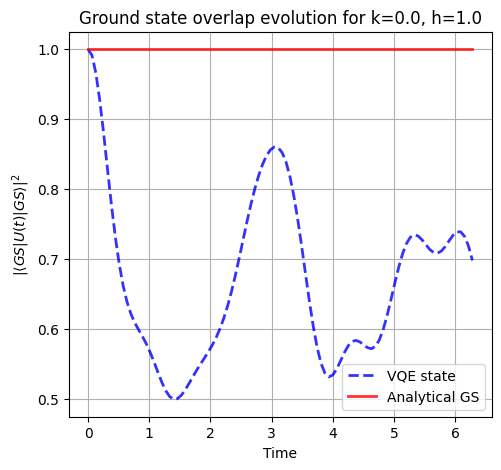

In [6]:
def U_t(H, t):
    H_mat = qml.matrix(H)
    return expm(-1.0j * H_mat * t)

H = get_H(N,k_val,h_val)
wires = range(N)
dev = qml.device("lightning.qubit", wires=N)

# Train VQE to get approximate ground state with shots
vqe=VQE(N,6,k_train,h_train, shots=1000)
best_energy, best_epoch, last_epoch, energy_history, lr_history=vqe.train_VQE()

print(f"VQE energy on it's own h and k: {best_energy}")
print(f"VQE energy{compute_energy_via_qnode(vqe.parameters_vqe).detach()}")
print(f"Theoretical energy: {energy.theoretical_energy(N,k_val,h_val)}")

# Get VQE ground state
@qml.qnode(dev)
def get_initial_state():
    vqe.ansatz(vqe.parameters_vqe)
    return qml.state()

vqe_gs = np.array(get_initial_state().detach().numpy())

# Get analytical ground state by diagonalizing H
H_matrix = qml.matrix(H)
eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)
analytical_gs = eigenvectors[:, 0]

print(f"\nVQE GS norm: {np.linalg.norm(vqe_gs)}")
print(f"Analytical GS norm: {np.linalg.norm(analytical_gs)}")

# Time evolution for both states
times = np.linspace(0, 2*np.pi, 100)
vqe_evol = []
analytical_evol = []

for t in times:
    # VQE state evolution
    evolved_vqe = U_t(H, t) @ vqe_gs
    overlap_vqe = np.abs(np.dot(np.conj(vqe_gs), evolved_vqe))**2
    vqe_evol.append(overlap_vqe)
    
    # Analytical state evolution
    evolved_analytical = U_t(H, t) @ analytical_gs
    overlap_analytical = np.abs(np.dot(np.conj(analytical_gs), evolved_analytical))**2
    analytical_evol.append(overlap_analytical)

# Plot comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(times, vqe_evol, linestyle="--", color="blue", label="VQE state", alpha=0.8, linewidth=2)
plt.plot(times, analytical_evol, linestyle="-", color="red", label="Analytical GS", alpha=0.8, linewidth=2)
plt.title(f"Ground state overlap evolution for k={k_val:.2}, h={h_val:.2}")
plt.xlabel("Time")
plt.ylabel(r"$|\langle GS|U(t)|GS\rangle|^2$")
plt.legend()
plt.grid()



In [7]:
@qml.qnode(dev)
def compute_energy_via_expval(params):
    vqe.ansatz(params)
    return qml.expval(H)

vqe_energy = float(compute_energy_via_expval(vqe.parameters_vqe))
theoretical_gs_energy = energy.theoretical_energy(N, k_val, h_val)
print(f"VQE energy: {vqe_energy}")
print(f"True GS energy: {theoretical_gs_energy}")
print(f"Error: {abs((vqe_energy - theoretical_gs_energy)/theoretical_gs_energy)*100}")

/tmp/ipykernel_354624/2616355083.py:6: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  vqe_energy = float(compute_energy_via_expval(vqe.parameters_vqe))


VQE energy: -5.406946659088135
True GS energy: -6.026671886444092
Error: 10.283042907714844


# Adding layer to solve divergence and removing shot induced noise

=== Training better VQE with more layers ===

--- Results Comparison ---
VQE (6 layers theoretical percs):  -5.461887, Error: 0.093714
VQE (12 layers): -5.528078, Error: 0.082731
True GS:         -6.026672


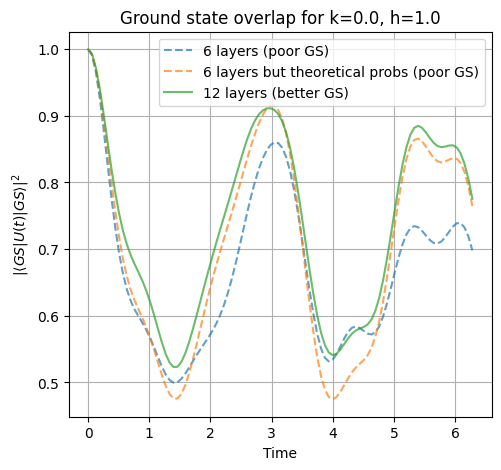

In [8]:
# Better VQE with more layers and longer training
print("=== Training better VQE with more layers ===")

H = get_H(N, k_val, h_val)
dev = qml.device("lightning.qubit", wires=N)

# Increase layers from 6 to 12 for better expressibility
vqe_improved = VQE(N, n_layers=12, k=k_train, h=h_train)  # shots=None for exact evaluation
vqe_no_shots = VQE(N, n_layers=6, k=k_train, h=h_train, shots=None)  # shots=None for exact evaluation
best_energy_imp, _, _, _, _ = vqe_improved.train_VQE(epochs=500)
best_energy_no_shot,  _, _, _, _ = vqe_no_shots.train_VQE(epochs=500)

@qml.qnode(dev)
def compute_energy_expval(vqe_to_compute,params):
    vqe_to_compute.ansatz(params)
    return qml.expval(H)

vqe_energy_improved = float(compute_energy_expval(vqe_improved,vqe_improved.parameters_vqe))
vqe_energy_no_shot = float(compute_energy_expval(vqe_no_shots,vqe_no_shots.parameters_vqe))
theoretical_gs_energy = energy.theoretical_energy(N, k_val, h_val)

print(f"\n--- Results Comparison ---")
print(f"VQE (6 layers theoretical percs):  {vqe_energy_no_shot:.6f}, Error: {abs((vqe_energy_no_shot - theoretical_gs_energy)/theoretical_gs_energy):.6f}")
print(f"VQE (12 layers): {vqe_energy_improved:.6f}, Error: {abs((vqe_energy_improved - theoretical_gs_energy)/theoretical_gs_energy):.6f}")
print(f"True GS:         {theoretical_gs_energy:.6f}")

# Now test time evolution with the better state
@qml.qnode(dev)
def get_state_for_evolution(vqe_for_state, params):
    vqe_for_state.ansatz(params)
    return qml.state()

initial_state_improved = np.array(get_state_for_evolution(vqe_improved,vqe_improved.parameters_vqe).detach().numpy())
initial_state_no_shot = np.array(get_state_for_evolution(vqe_no_shots,vqe_no_shots.parameters_vqe).detach().numpy())
times = np.linspace(0, 2*np.pi, 100)
exact_evol_improved = []
exact_evol_no_shots = []

for t in times:
    evolved_state = U_t(H, t) @ initial_state_improved
    overlap = np.abs(np.dot(np.conj(initial_state_improved), evolved_state))**2
    exact_evol_improved.append(overlap)

    evolved_state_no_shots = U_t(H, t) @ initial_state_no_shot
    overlap_no_shots = np.abs(np.dot(np.conj(initial_state_no_shot), evolved_state_no_shots))**2
    exact_evol_no_shots.append(overlap_no_shots)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(times, vqe_evol, linestyle="--", label="6 layers (poor GS)", alpha=0.7)
plt.plot(times, exact_evol_no_shots, linestyle="--", label="6 layers but theoretical probs (poor GS)", alpha=0.7)
plt.plot(times, exact_evol_improved, linestyle="-", label="12 layers (better GS)", alpha=0.7)
plt.title(f"Ground state overlap for k={k_val:.2}, h={h_val:.2}")
plt.xlabel("Time")
plt.ylabel(r"$|\langle GS|U(t)|GS\rangle|^2$")
plt.legend()
plt.grid()

# plt.subplot(1, 2, 2)
# plt.plot(times, np.array(exact_evol) - 1, label="6 layers (error)", alpha=0.7)
# plt.plot(times, np.array(exact_evol_improved) - 1, label="12 layers (error)", alpha=0.7)
# plt.title("Deviation from perfect overlap")
# plt.xlabel("Time")
# plt.ylabel(r"$|\langle GS|U(t)|GS\rangle|^2 - 1$")
# plt.legend()
# plt.grid()
# plt.tight_layout()
# plt.show()


## Time evolution circuit with Trotterization

In [9]:
# N = 5
# k = 0.5
# h = 0.5

H = get_H(N,k_val,h_val)

wires = range(N)
dev = qml.device("lightning.qubit", wires=N)




# create the circuit that evolves the system in time
@qml.qnode(dev)
def time_evolution_circuit(H, T):
    #Evolve the system via a sequence of short approximate Trotter time steps
    #https://docs.pennylane.ai/en/stable/code/api/pennylane.TrotterProduct.html
    qml.TrotterProduct(H, time=T, n=math.ceil(T / 0.1)+1, order=2)

    # return the final probabilities
    return qml.probs(wires=range(N))

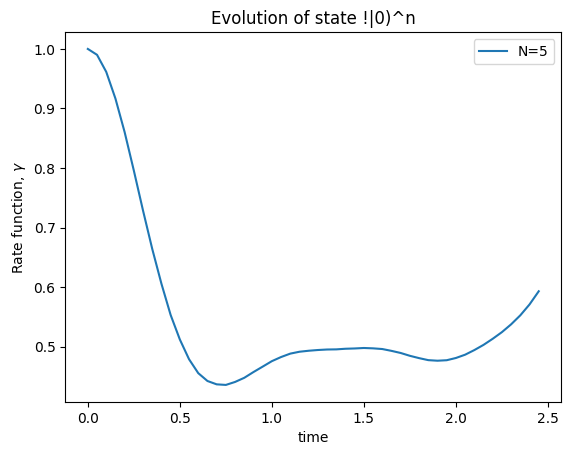

In [10]:
prob_list = []

# time step size for time evolution
T_start = 0
deltaT = 0.05
num_time_steps = 50

for i in range(num_time_steps):
    probability_list = time_evolution_circuit(H, T_start + i * deltaT)
    prob_list.append(probability_list[0])

plt.plot(np.linspace(T_start, T_start + deltaT * (num_time_steps-1), num_time_steps), prob_list)
plt.xlabel("time")
plt.ylabel(r"Rate function, $\gamma$")
plt.title("Evolution of state !|0)^n")
plt.legend(["N=" + str(N)])
plt.show()


-3.493999974685721
-6.026672
[ 1.27764496e-02+0.j -4.49098647e-01+0.j -4.41242156e-01+0.j
 -1.18752041e-02+0.j  7.51425585e-02+0.j -2.31473614e-03+0.j
  8.69131495e-03+0.j  6.76624077e-03+0.j  5.12138777e-01+0.j
 -6.96626901e-03+0.j  2.77581597e-03+0.j  1.92537282e-01+0.j
  9.70653774e-05+0.j -1.09573341e-01+0.j -5.20838175e-04+0.j
 -7.58258278e-03-0.j  4.30829446e-01+0.j -6.30893741e-03+0.j
 -8.87262392e-03+0.j  1.63209062e-01+0.j  1.87467604e-02+0.j
  8.81784534e-03+0.j  8.89861998e-02+0.j -4.61209463e-03+0.j
  1.79579054e-02+0.j -1.83597584e-01+0.j -1.70512334e-01+0.j
 -1.44895820e-03+0.j  4.18388295e-02+0.j -2.15083888e-02-0.j
  9.38609366e-04+0.j  1.23453635e-03+0.j]


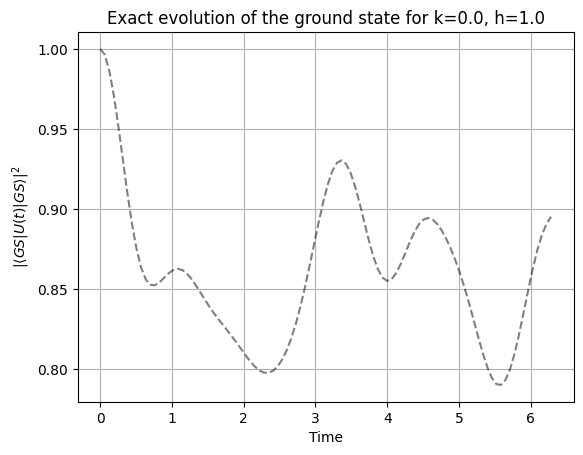

In [11]:
def U_t(H, t):
    H_mat = qml.matrix(H)
    return expm(-1.0j * H_mat * t)

# N = 5
# k = 0.5
# h = 0.5

H = get_H(N,k_val,h_val)
wires = range(N)
dev = qml.device("lightning.qubit", wires=N)


vqe=VQE(N,6,k_train,h_train)
best_energy, best_epoch, last_epoch, energy_history, lr_history=vqe.train_VQE()

print(best_energy)
print(energy.theoretical_energy(N,k_val,h_val))
@qml.qnode(dev)
def get_initial_state():
    vqe.ansatz(vqe.parameters_vqe)
    return qml.state()
import numpy as np
initial_state = np.array(get_initial_state().detach().numpy())
print(initial_state)
times = np.linspace(0, 2*np.pi, 100)
exact_evol = []
theor_evol = []

# H_matrix = qml.matrix(H)
# theor_eigenvectors = np.linalg.eigh(H_matrix)[1]
# theor_gs = theor_eigenvectors[:, 0]

for t in times:
    evolved_state = U_t(H, t) @ initial_state
    overlap = np.abs(np.dot(np.conj(initial_state), evolved_state))**2
    exact_evol.append(overlap)

    # evolved_state = U_t(H, t) @ theor_gs
    # overlap = np.abs(np.dot(np.conj(theor_gs), evolved_state))**2
    # theor_evol.append(overlap)

plt.plot(times, exact_evol, linestyle="--", color="black", alpha=0.5)
# plt.plot(times, theor_evol, linestyle="-", color="black", alpha=0.8)
plt.title(f"Exact evolution of the ground state for k={k_val:.2}, h={h_val:.2}")
plt.xlabel("Time")
plt.ylabel(r"$|\langle GS|U(t)|GS\rangle|^2$")
plt.grid()
plt.show()

## Magnetization time evolution

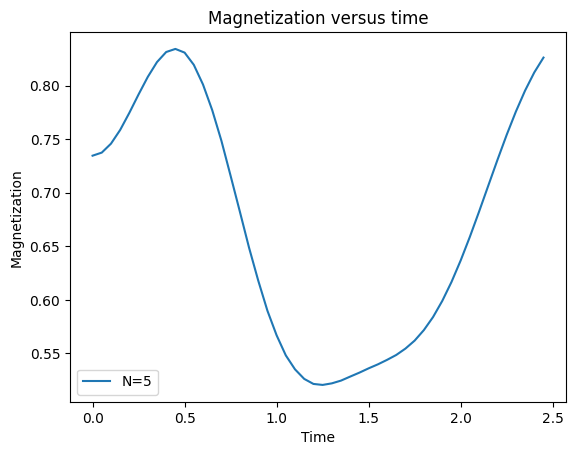

In [12]:
# Find ground state once
# ground_state_params, _ = find_ground_state(N, k, h, max_iters=500, tolerance=1e-07)


# Define a function to calculate magnetization at time t
def calculate_magnetization_at_time(H, t, N, k, h):
    """Calculate magnetization after time evolution"""
    
    # Create a device for the circuit
    dev = qml.device("lightning.qubit", wires=range(N))
    
    @qml.qnode(dev)
    def magnetization_circuit():
        # Prepare the ground state
        #create_ansatz(ground_state_params, N)
        vqe_no_shots.ansatz(vqe_no_shots.parameters_vqe)
        # Apply time evolution
        qml.TrotterProduct(H, time=t, n=math.ceil(t / 0.1)+1, order=2)
        # Return magnetization expectation value
        return qml.expval(magnetization_op(N))
    
    return magnetization_circuit()

# Calculate magnetization over time
magnetization_list = []
deltaT = 0.05
num_time_steps = 50

for i in range(num_time_steps):
    mag = calculate_magnetization_at_time(H, i * deltaT, N, k_val, h_val)
    magnetization_list.append(mag.detach().numpy())

plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), magnetization_list)
plt.xlabel("Time")
plt.ylabel("Magnetization")
plt.title("Magnetization versus time")
plt.legend(["N=" + str(N)])
plt.show()

To see if a dynamical phase transition happens, let’s consider an observable called the rate function $\gamma$. It depends on the overlap between the quantum state that we start with and the final state at some time $t$. More specifically,
$$\gamma = -\frac{1}{N} \log_{e} (|G|^{2}),$$
where $G = \langle \psi_{i} | \psi_{f}\rangle$, $| \psi_{i}\rangle$ and $| \psi_{f}\rangle$ and are the initial and final states, respectively. As the system evolves, we’ll keep calculating $\gamma$. If it changes discontinuously, then a dynamical phase transition has happened.

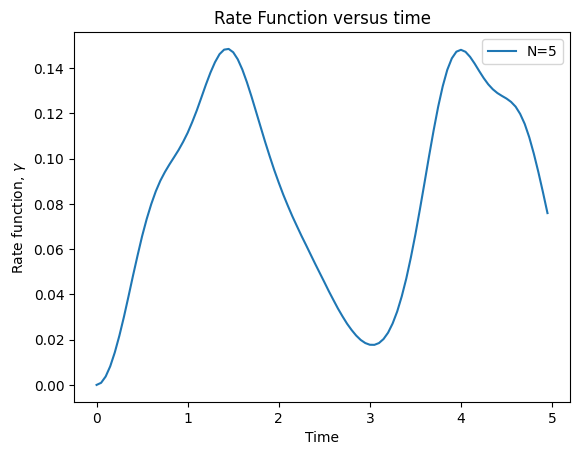

In [13]:
def rate_function(H, T, N, k, h):
    """Calculate the rate function gamma = -1/N * log(|<ψ_i|ψ_f>|^2)"""
    
    dev = qml.device("lightning.qubit", wires=range(N))

    # Create the initial ground state and final state separately
    @qml.qnode(dev)
    def overlap_circuit():
        vqe_no_shots.ansatz(vqe_no_shots.parameters_vqe)
        qml.TrotterProduct(H, time=T, n=math.ceil(T / 0.1)+1, order=2)
        return qml.state()
        
    @qml.qnode(dev)
    def initial_state_circuit():
        vqe_no_shots.ansatz(vqe_no_shots.parameters_vqe)
        return qml.state()

    final_state = overlap_circuit().detach().numpy()
    initial_state = initial_state_circuit().detach().numpy()
    
    # Calculate overlap
    overlap = np.abs(np.dot(np.conj(initial_state), final_state))**2
    
    return -1/N * np.log(overlap + 1e-15)  # Add small epsilon to avoid log(0)

# Calculate rate function over time
rate_function_list = []
deltaT = 0.05
num_time_steps = 100

for i in range(num_time_steps):
    rate = rate_function(H, i * deltaT, N, k_val, h_val)
    rate_function_list.append(rate)
    # print(i)

plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), rate_function_list)
plt.xlabel("Time")
plt.ylabel(r"Rate function, $\gamma$")
plt.title("Rate Function versus time")
plt.legend(["N=" + str(N)])
plt.show()